# Project 5

PGD evasion, label-flip poisoning, and membership inference on the COMPAS dataset.
This notebook continues from Copy_of_Lecture_05_security.ipynb.

## Setup

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# Load COMPAS data from ProPublica's GitHub
URL = ("https://raw.githubusercontent.com/propublica/compas-analysis"
       "/master/compas-scores-two-years.csv")
df = pd.read_csv(URL)

# Standard ProPublica filters
df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']

# Feature selection (same as the lecture notebook)
FEATURES = ['age', 'priors_count', 'juv_fel_count',
            'juv_misd_count', 'juv_other_count',
            'c_charge_degree', 'sex']
TARGET = 'two_year_recid'

df_m = df[FEATURES + [TARGET, 'race']].dropna()
df_m = pd.get_dummies(df_m, columns=['c_charge_degree', 'sex'], drop_first=True)

X = df_m.drop(columns=[TARGET, 'race']).astype(float)
y = df_m[TARGET].values
race = df_m['race'].values
FEATURE_NAMES = list(X.columns)

# Train/test split, stratified on the target
X_tr, X_te, y_tr, y_te, r_tr, r_te = train_test_split(
    X, y, race, test_size=0.3, random_state=42, stratify=y)

# Scale features
sc = StandardScaler()
Xs_tr = sc.fit_transform(X_tr)
Xs_te = sc.transform(X_te)

# Train both target models
lr = LogisticRegression(max_iter=1000, random_state=42).fit(Xs_tr, y_tr)
gbt = GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                 random_state=42).fit(Xs_tr, y_tr)

# Decision threshold for binary predictions
THR = 0.5

def fpr_by_group(y_true, y_pred, groups):
    # FPR computed only on truly-negative cases, broken out by group
    mask = (y_true == 0)
    return (pd.DataFrame({'pred': y_pred[mask], 'group': groups[mask]})
              .groupby('group')['pred'].mean())

def air(fpr_ref, fpr_prot):
    # AIR = protected FPR / reference FPR (Caucasian = reference, AA = protected)
    return fpr_prot / fpr_ref if (fpr_ref is not None and fpr_ref > 0) else np.nan

# Compute and store clean baselines for both models
baselines = {}
for name, mdl in [('LR', lr), ('GBT', gbt)]:
    pred = (mdl.predict_proba(Xs_te)[:, 1] >= THR).astype(int)
    fpr = fpr_by_group(y_te, pred, r_te)
    aa, ca = fpr.get('African-American'), fpr.get('Caucasian')
    auc_te = roc_auc_score(y_te, mdl.predict_proba(Xs_te)[:, 1])
    auc_tr = roc_auc_score(y_tr, mdl.predict_proba(Xs_tr)[:, 1])
    baselines[name] = {'fpr_aa': aa, 'fpr_ca': ca, 'air': air(ca, aa),
                       'auc_te': auc_te, 'auc_tr': auc_tr,
                       'gen_gap': auc_tr - auc_te}
    print(f"{name}: AUC_te={auc_te:.3f}, AUC_tr={auc_tr:.3f}, "
          f"FPR_AA={aa:.3f}, FPR_CA={ca:.3f}, AIR={air(ca, aa):.3f}")

LR: AUC_te=0.735, AUC_tr=0.727, FPR_AA=0.281, FPR_CA=0.143, AIR=1.961
GBT: AUC_te=0.718, AUC_tr=0.798, FPR_AA=0.317, FPR_CA=0.178, AIR=1.782


## Part 1: PGD evasion audit on LR and GBT

In [ ]:
# PGD attack for logistic regression (closed-form gradient sign)
def pgd_lr(model, X, epsilon, alpha=0.05, n_iter=40):
    coef = model.coef_[0]
    X_adv = X.copy()
    for _ in range(n_iter):
        # Step in the direction that increases loss, then project back into L-inf ball
        X_adv = X_adv + alpha * np.sign(coef)[None, :]
        X_adv = np.clip(X_adv, X - epsilon, X + epsilon)
    return X_adv

# PGD attack for GBT (no analytic gradient, so use central differences)
def pgd_gbt(model, X, epsilon, alpha=0.05, n_iter=20, h=1e-2):
    X_adv = X.copy()
    d = X.shape[1]
    for _ in range(n_iter):
        # Numerical gradient of P(y=1|x) per feature
        grad = np.zeros_like(X_adv)
        for j in range(d):
            Xp = X_adv.copy(); Xp[:, j] += h
            Xm = X_adv.copy(); Xm[:, j] -= h
            grad[:, j] = (model.predict_proba(Xp)[:, 1]
                          - model.predict_proba(Xm)[:, 1]) / (2 * h)
        X_adv = X_adv + alpha * np.sign(grad)
        X_adv = np.clip(X_adv, X - epsilon, X + epsilon)
    return X_adv

# Sweep epsilon for both models, including eps=0 as a sanity check
EPSILONS = [0.0, 0.25, 0.5, 1.0, 2.0]
pgd_results = []

for model_name, mdl, atk in [('LR', lr, pgd_lr), ('GBT', gbt, pgd_gbt)]:
    for eps in EPSILONS:
        X_adv = Xs_te if eps == 0.0 else atk(mdl, Xs_te, epsilon=eps)
        pred = (mdl.predict_proba(X_adv)[:, 1] >= THR).astype(int)
        fpr = fpr_by_group(y_te, pred, r_te)
        aa, ca = fpr.get('African-American'), fpr.get('Caucasian')
        pgd_results.append({'model': model_name, 'epsilon': eps,
                            'FPR_AA': aa, 'FPR_CA': ca, 'AIR': air(ca, aa)})

df_pgd = pd.DataFrame(pgd_results)
print(df_pgd.round(3).to_string(index=False))

# Find the smallest epsilon at which AIR drops below 0.80 (4/5ths rule)
print()
for m in ['LR', 'GBT']:
    sub = df_pgd[(df_pgd['model'] == m) & (df_pgd['AIR'] < 0.80)]
    if len(sub):
        print(f"{m}: AIR drops below 0.80 at epsilon = {sub.iloc[0]['epsilon']}")
    else:
        print(f"{m}: AIR never drops below 0.80 in the tested range")

model  epsilon  FPR_AA  FPR_CA   AIR
   LR     0.00   0.281   0.143 1.961
   LR     0.25   0.569   0.370 1.535
   LR     0.50   0.791   0.560 1.411
   LR     1.00   0.978   0.884 1.106
   LR     2.00   1.000   1.000 1.000
  GBT     0.00   0.317   0.178 1.782
  GBT     0.25   0.317   0.178 1.782
  GBT     0.50   0.317   0.178 1.782
  GBT     1.00   0.317   0.178 1.782
  GBT     2.00   0.317   0.178 1.782

LR: AIR never drops below 0.80 in the tested range
GBT: AIR never drops below 0.80 in the tested range


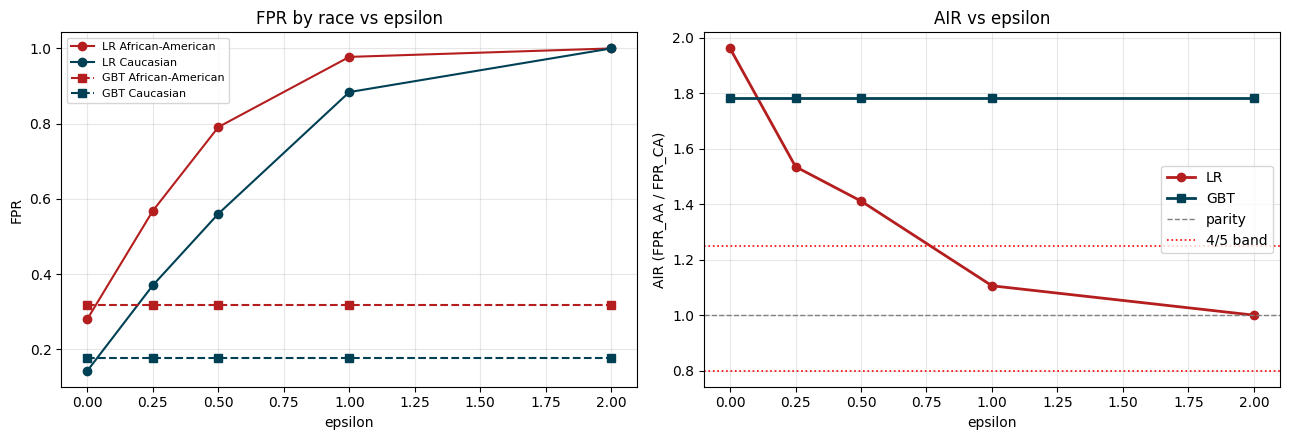

In [ ]:
# Plot: FPR by race vs epsilon, and AIR vs epsilon, for both models
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for m, ls, mk in [('LR', '-', 'o'), ('GBT', '--', 's')]:
    sub = df_pgd[df_pgd['model'] == m]
    ax.plot(sub['epsilon'], sub['FPR_AA'], ls, marker=mk, color='#B41E1E',
            label=f'{m} African-American')
    ax.plot(sub['epsilon'], sub['FPR_CA'], ls, marker=mk, color='#004055',
            label=f'{m} Caucasian')
ax.set_xlabel('epsilon')
ax.set_ylabel('FPR')
ax.set_title('FPR by race vs epsilon')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
for m, c, mk in [('LR', '#B41E1E', 'o'), ('GBT', '#004055', 's')]:
    sub = df_pgd[df_pgd['model'] == m]
    ax.plot(sub['epsilon'], sub['AIR'], '-', marker=mk, color=c, lw=2, label=m)
ax.axhline(1.0, color='gray', ls='--', lw=1, label='parity')
ax.axhline(0.8, color='red', ls=':', lw=1.2, label='4/5 band')
ax.axhline(1.25, color='red', ls=':', lw=1.2)
ax.set_xlabel('epsilon')
ax.set_ylabel('AIR (FPR_AA / FPR_CA)')
ax.set_title('AIR vs epsilon')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Part 2: Label-flip poisoning loop, both target groups, plus PSI drift check

The lecture notebook only targets African-American defendants. Here I run the same
attack twice (once for each race) and overlay the AUC/AIR degradation curves on
shared axes, then check whether a PSI drift monitor would catch the attack.

In [ ]:
# Same poisoning function as the lecture notebook
def poison_label_flip(y_train, race_train, poison_rate, target_race, seed=0):
    rng = np.random.default_rng(seed)
    y_p = y_train.copy()
    # Eligible records: target race AND truly recidivist (label = 1)
    candidates = np.where((race_train == target_race) & (y_train == 1))[0]
    n_flip = int(len(candidates) * poison_rate)
    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_p[flip_idx] = 0  # flip from high-risk to low-risk
    return y_p, n_flip

# Sweep poison rates for both target groups
POISON_RATES = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
TARGETS = ['African-American', 'Caucasian']

baseline_auc_lr = baselines['LR']['auc_te']
BASELINE_AIR = baselines['LR']['air']

poison_records = []
poisoned_models = {}  # keep poisoned models so we can run PSI on their outputs

for target in TARGETS:
    for rate in POISON_RATES:
        y_p, n_flip = poison_label_flip(y_tr, r_tr, rate, target)
        # Retrain LR on poisoned labels (same features, same scaler)
        lr_p = LogisticRegression(max_iter=1000, random_state=42).fit(Xs_tr, y_p)
        pred = (lr_p.predict_proba(Xs_te)[:, 1] >= THR).astype(int)
        auc = roc_auc_score(y_te, lr_p.predict_proba(Xs_te)[:, 1])
        fpr = fpr_by_group(y_te, pred, r_te)
        aa, ca = fpr.get('African-American'), fpr.get('Caucasian')
        poison_records.append({'target': target, 'poison_rate': rate,
                               'n_flipped': n_flip, 'AUC': auc,
                               'delta_AUC': auc - baseline_auc_lr,
                               'FPR_AA': aa, 'FPR_CA': ca,
                               'AIR': air(ca, aa)})
        poisoned_models[(target, rate)] = lr_p

df_poison = pd.DataFrame(poison_records)
print(df_poison.round(3).to_string(index=False))

          target  poison_rate  n_flipped   AUC  delta_AUC  FPR_AA  FPR_CA   AIR
African-American         0.00          0 0.735      0.000   0.281   0.143 1.961
African-American         0.02         23 0.733     -0.002   0.270   0.136 1.986
African-American         0.05         57 0.734     -0.001   0.240   0.123 1.948
African-American         0.08         92 0.732     -0.002   0.213   0.116 1.840
African-American         0.10        115 0.735      0.000   0.196   0.101 1.931
African-American         0.15        172 0.732     -0.003   0.153   0.072 2.134
African-American         0.20        230 0.732     -0.002   0.130   0.054 2.399
African-American         0.25        287 0.730     -0.004   0.112   0.042 2.677
African-American         0.30        345 0.731     -0.003   0.097   0.032 3.010
       Caucasian         0.00          0 0.735      0.000   0.281   0.143 1.961
       Caucasian         0.02         11 0.734     -0.001   0.274   0.141 1.948
       Caucasian         0.05         29

In [ ]:
# Stealth zone: AUC drop within 2pp AND AIR outside [0.80, 1.25]
# (model still looks healthy on AUC but violates the 4/5ths rule)
print("Stealth zone (AUC drop <= 2pp AND AIR not in [0.80, 1.25]):")
for target in TARGETS:
    sub = df_poison[df_poison['target'] == target].copy()
    mask = (sub['delta_AUC'] >= -0.02) & ((sub['AIR'] < 0.80) | (sub['AIR'] > 1.25))
    stealth = sub[mask]
    print(f"\nTarget = {target}")
    if len(stealth):
        print(f"  poison rates: {stealth['poison_rate'].tolist()}")
        print(f"  AIR range: [{stealth['AIR'].min():.3f}, {stealth['AIR'].max():.3f}]")
        print(f"  delta_AUC range: [{stealth['delta_AUC'].min():.3f}, "
              f"{stealth['delta_AUC'].max():.3f}]")
    else:
        print("  empty (no stealth zone in this range)")

Stealth zone (AUC drop <= 2pp AND AIR not in [0.80, 1.25]):

Target = African-American
  poison rates: [0.0, 0.02, 0.05, 0.08, 0.1, 0.15, 0.2, 0.25, 0.3]
  AIR range: [1.840, 3.010]
  delta_AUC range: [-0.004, 0.000]

Target = Caucasian
  poison rates: [0.0, 0.02, 0.05, 0.08, 0.1, 0.15, 0.2, 0.25, 0.3]
  AIR range: [1.842, 2.043]
  delta_AUC range: [-0.003, 0.001]


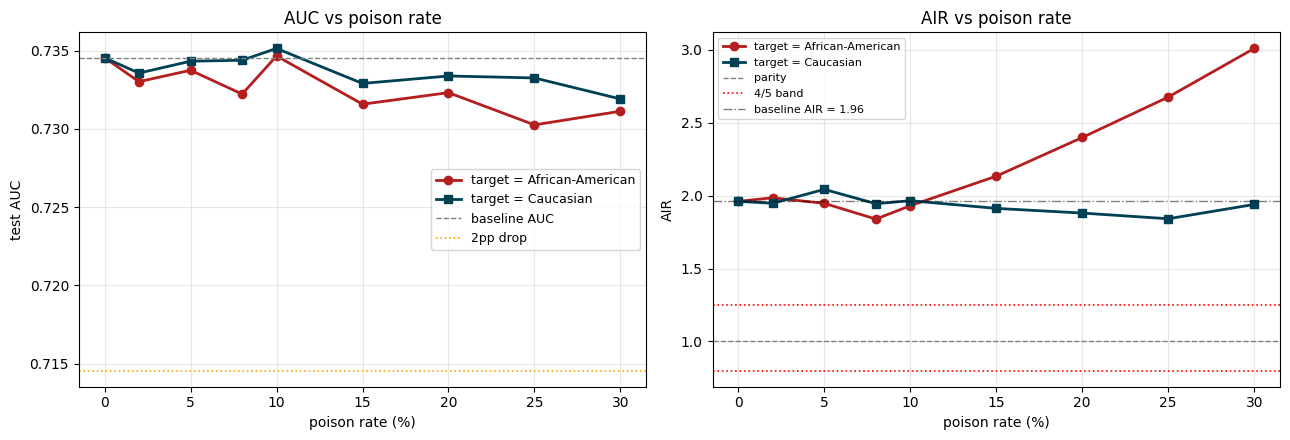

In [ ]:
# AUC and AIR curves for both target groups on shared axes
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x_pct = np.array(POISON_RATES) * 100

ax = axes[0]
for target, color, mk in [('African-American', '#B41E1E', 'o'),
                          ('Caucasian', '#004055', 's')]:
    sub = df_poison[df_poison['target'] == target]
    ax.plot(x_pct, sub['AUC'], '-', marker=mk, color=color, lw=2,
            label=f'target = {target}')
ax.axhline(baseline_auc_lr, color='gray', ls='--', lw=1, label='baseline AUC')
ax.axhline(baseline_auc_lr - 0.02, color='orange', ls=':', lw=1.2,
           label='2pp drop')
ax.set_xlabel('poison rate (%)')
ax.set_ylabel('test AUC')
ax.set_title('AUC vs poison rate')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
for target, color, mk in [('African-American', '#B41E1E', 'o'),
                          ('Caucasian', '#004055', 's')]:
    sub = df_poison[df_poison['target'] == target]
    ax.plot(x_pct, sub['AIR'], '-', marker=mk, color=color, lw=2,
            label=f'target = {target}')
ax.axhline(1.0, color='gray', ls='--', lw=1, label='parity')
ax.axhline(0.8, color='red', ls=':', lw=1.2, label='4/5 band')
ax.axhline(1.25, color='red', ls=':', lw=1.2)
ax.axhline(BASELINE_AIR, color='black', ls='-.', lw=1, alpha=0.5,
           label=f'baseline AIR = {BASELINE_AIR:.2f}')
ax.set_xlabel('poison rate (%)')
ax.set_ylabel('AIR')
ax.set_title('AIR vs poison rate')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Population Stability Index (industry-standard drift monitor)
def psi(reference, current, n_bins=10):
    eps = 1e-6
    edges = np.quantile(reference, np.linspace(0, 1, n_bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    p_ref = np.histogram(reference, bins=edges)[0] / len(reference) + eps
    p_cur = np.histogram(current, bins=edges)[0] / len(current) + eps
    return float(np.sum((p_cur - p_ref) * np.log(p_cur / p_ref)))

# Check 1: PSI on input features (clean train vs poisoned train)
# Label-flip leaves features untouched, so feature PSI should be exactly zero.
print("PSI on training features (clean vs poisoned):")
for j, f in enumerate(FEATURE_NAMES):
    val = psi(Xs_tr[:, j], Xs_tr[:, j])
    flag = "fires" if val >= 0.10 else "ok"
    print(f"  {flag:6s}  {f:25s}  PSI = {val:.4f}")
print("\nFeatures are unchanged by label-flip, so a feature-level PSI monitor")
print("does not detect this attack.")

# Check 2: PSI on output prediction distribution (clean LR vs poisoned LR)
# This is more sensitive because poisoned LR shifts its score distribution.
print("\nPSI on output prediction scores (clean LR vs poisoned LR on test set):")
p_clean = lr.predict_proba(Xs_te)[:, 1]
for target in TARGETS:
    for rate in [0.10, 0.20, 0.30]:
        lr_p = poisoned_models[(target, rate)]
        p_pois = lr_p.predict_proba(Xs_te)[:, 1]
        val = psi(p_clean, p_pois)
        flag = "fires" if val >= 0.10 else "ok"
        print(f"  {flag:6s}  target={target:20s} rate={rate:.0%}  PSI={val:.4f}")

PSI on training features (clean vs poisoned):
  ok      age                        PSI = 0.0000
  ok      priors_count               PSI = 0.0000
  ok      juv_fel_count              PSI = 0.0000
  ok      juv_misd_count             PSI = 0.0000
  ok      juv_other_count            PSI = 0.0000
  ok      c_charge_degree_M          PSI = 0.0000
  ok      sex_Male                   PSI = 0.0000

Features are unchanged by label-flip, so a feature-level PSI monitor
does not detect this attack.

PSI on output prediction scores (clean LR vs poisoned LR on test set):
  ok      target=African-American     rate=10%  PSI=0.0552
  fires   target=African-American     rate=20%  PSI=0.1740
  fires   target=African-American     rate=30%  PSI=0.3318
  ok      target=Caucasian            rate=10%  PSI=0.0152
  ok      target=Caucasian            rate=20%  PSI=0.0480
  ok      target=Caucasian            rate=30%  PSI=0.0786


## Part 3: Membership inference depth

Shadow-model MI attack on both LR and GBT, then a regularization sweep on LR
to see how L2 strength (parameter C) trades off privacy, accuracy, and fairness.

In [ ]:
# Generic shadow-MI pipeline so we can call it for any target model
def shadow_mi(target_model, X_tr, y_tr, X_te, shadow_factory,
              n_shadow=10, seed=0):
    # Train n_shadow shadow models on random 50/50 splits of the training data
    train_confs, test_confs = [], []
    sss = StratifiedShuffleSplit(n_splits=n_shadow, test_size=0.5, random_state=seed)
    for tr_i, te_i in sss.split(X_tr, y_tr):
        s = shadow_factory().fit(X_tr[tr_i], y_tr[tr_i])
        train_confs.append(s.predict_proba(X_tr[tr_i]).max(axis=1))
        test_confs.append(s.predict_proba(X_tr[te_i]).max(axis=1))

    # Build (confidence, member?) dataset and fit a meta-classifier
    mi_X = np.concatenate(train_confs + test_confs).reshape(-1, 1)
    mi_y = np.concatenate([np.ones(len(c)) for c in train_confs] +
                          [np.zeros(len(c)) for c in test_confs])
    meta = DecisionTreeClassifier(max_depth=6, random_state=seed).fit(mi_X, mi_y)

    # Evaluate the meta-classifier on the actual target model's outputs
    conf_tr = target_model.predict_proba(X_tr).max(axis=1).reshape(-1, 1)
    conf_te = target_model.predict_proba(X_te).max(axis=1).reshape(-1, 1)
    s_tr = meta.predict_proba(conf_tr)[:, 1]
    s_te = meta.predict_proba(conf_te)[:, 1]
    labels = np.concatenate([np.ones(len(X_tr)), np.zeros(len(X_te))])
    scores = np.concatenate([s_tr, s_te])
    return roc_auc_score(labels, scores), conf_tr.ravel(), conf_te.ravel()

# Run MI attack on both target models, using matching shadow architectures
mi_auc_lr, conf_tr_lr, conf_te_lr = shadow_mi(
    lr, Xs_tr, y_tr, Xs_te,
    shadow_factory=lambda: LogisticRegression(max_iter=1000, random_state=42))

mi_auc_gbt, conf_tr_gbt, conf_te_gbt = shadow_mi(
    gbt, Xs_tr, y_tr, Xs_te,
    shadow_factory=lambda: GradientBoostingClassifier(
        n_estimators=100, max_depth=4, random_state=42))

print(f"LR  MI AUC = {mi_auc_lr:.3f}, gen_gap = {baselines['LR']['gen_gap']:+.3f}")
print(f"GBT MI AUC = {mi_auc_gbt:.3f}, gen_gap = {baselines['GBT']['gen_gap']:+.3f}")

LR  MI AUC = 0.497, gen_gap = -0.008
GBT MI AUC = 0.500, gen_gap = +0.080


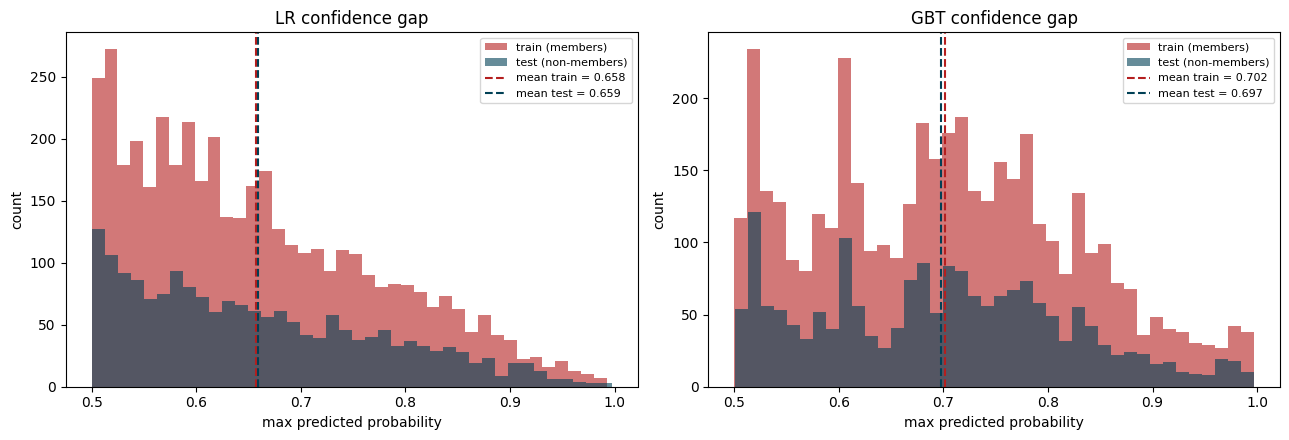


LR  gen_gap = -0.008, MI AUC = 0.497
GBT gen_gap = +0.080, MI AUC = 0.500


In [ ]:
# Side-by-side confidence histograms for members vs non-members
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, name, ctr, cte in [(axes[0], 'LR', conf_tr_lr, conf_te_lr),
                           (axes[1], 'GBT', conf_tr_gbt, conf_te_gbt)]:
    ax.hist(ctr, bins=40, alpha=0.6, color='#B41E1E', label='train (members)')
    ax.hist(cte, bins=40, alpha=0.6, color='#004055', label='test (non-members)')
    ax.axvline(ctr.mean(), color='#B41E1E', ls='--', lw=1.5,
               label=f'mean train = {ctr.mean():.3f}')
    ax.axvline(cte.mean(), color='#004055', ls='--', lw=1.5,
               label=f'mean test = {cte.mean():.3f}')
    ax.set_xlabel('max predicted probability')
    ax.set_ylabel('count')
    ax.set_title(f'{name} confidence gap')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Quick check on whether generalization gap aligns with MI vulnerability
print(f"\nLR  gen_gap = {baselines['LR']['gen_gap']:+.3f}, MI AUC = {mi_auc_lr:.3f}")
print(f"GBT gen_gap = {baselines['GBT']['gen_gap']:+.3f}, MI AUC = {mi_auc_gbt:.3f}")

    C  MI_AUC  AUC_test  gen_gap  FPR_AA  FPR_CA   AIR
 0.01   0.499     0.732   -0.006   0.272   0.138 1.966
 0.10   0.505     0.734   -0.007   0.279   0.143 1.946
 1.00   0.497     0.735   -0.008   0.281   0.143 1.961
10.00   0.499     0.735   -0.008   0.281   0.143 1.961


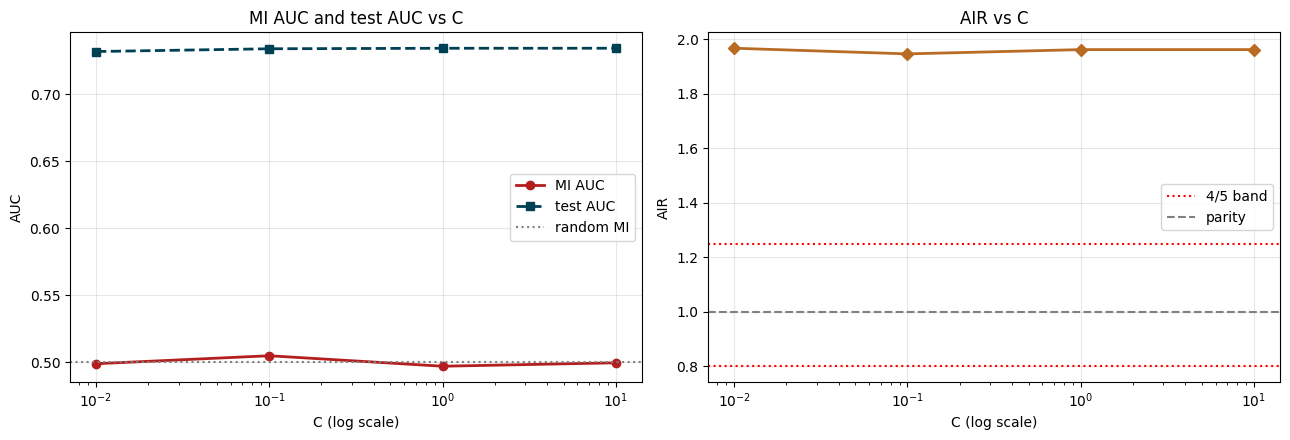

In [ ]:
# L2 regularization sweep on LR: vary C and recompute MI AUC each time
C_grid = [0.01, 0.1, 1.0, 10.0]
l2_records = []

for C in C_grid:
    lr_c = LogisticRegression(C=C, max_iter=1000, random_state=42).fit(Xs_tr, y_tr)
    auc_tr = roc_auc_score(y_tr, lr_c.predict_proba(Xs_tr)[:, 1])
    auc_te = roc_auc_score(y_te, lr_c.predict_proba(Xs_te)[:, 1])
    pred = (lr_c.predict_proba(Xs_te)[:, 1] >= THR).astype(int)
    fpr = fpr_by_group(y_te, pred, r_te)
    aa, ca = fpr.get('African-American'), fpr.get('Caucasian')
    # Shadow models use the same C as the target
    mi_auc, _, _ = shadow_mi(
        lr_c, Xs_tr, y_tr, Xs_te,
        shadow_factory=lambda C=C: LogisticRegression(
            C=C, max_iter=1000, random_state=42))
    l2_records.append({'C': C, 'MI_AUC': mi_auc, 'AUC_test': auc_te,
                       'gen_gap': auc_tr - auc_te,
                       'FPR_AA': aa, 'FPR_CA': ca, 'AIR': air(ca, aa)})

df_l2 = pd.DataFrame(l2_records)
print(df_l2.round(3).to_string(index=False))

# Plot the privacy/accuracy tradeoff and the side-effect on fairness
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(df_l2['C'], df_l2['MI_AUC'], 'o-', color='#B41E1E', lw=2, label='MI AUC')
ax.plot(df_l2['C'], df_l2['AUC_test'], 's--', color='#004055', lw=2,
        label='test AUC')
ax.axhline(0.5, color='gray', ls=':', label='random MI')
ax.set_xscale('log')
ax.set_xlabel('C (log scale)')
ax.set_ylabel('AUC')
ax.set_title('MI AUC and test AUC vs C')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(df_l2['C'], df_l2['AIR'], 'D-', color='#B96B23', lw=2)
ax.axhline(0.80, color='red', ls=':', label='4/5 band')
ax.axhline(1.25, color='red', ls=':')
ax.axhline(1.0, color='gray', ls='--', label='parity')
ax.set_xscale('log')
ax.set_xlabel('C (log scale)')
ax.set_ylabel('AIR')
ax.set_title('AIR vs C')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Final summary - paste this output back to me

In [ ]:
# Single block summarizing all results for the written report
print("BASELINES")
for name, b in baselines.items():
    print(f"{name}: AUC_te={b['auc_te']:.3f} AUC_tr={b['auc_tr']:.3f} "
          f"gen_gap={b['gen_gap']:+.3f} FPR_AA={b['fpr_aa']:.3f} "
          f"FPR_CA={b['fpr_ca']:.3f} AIR={b['air']:.3f}")

print("\nPART 1 - PGD")
print(df_pgd.round(3).to_string(index=False))
print()
for m in ['LR', 'GBT']:
    sub = df_pgd[(df_pgd['model'] == m) & (df_pgd['AIR'] < 0.80)]
    print(f"{m}: AIR<0.80 first at eps = "
          + (str(sub.iloc[0]['epsilon']) if len(sub) else 'never'))

print("\nPART 2 - POISONING")
print(df_poison.round(3).to_string(index=False))
print()
for target in TARGETS:
    sub = df_poison[df_poison['target'] == target]
    mask = (sub['delta_AUC'] >= -0.02) & ((sub['AIR'] < 0.80) | (sub['AIR'] > 1.25))
    rates = sub[mask]['poison_rate'].tolist()
    print(f"stealth zone target={target}: rates = {rates}")

print("\nPART 3 - MI")
print(f"LR  MI AUC = {mi_auc_lr:.3f}")
print(f"GBT MI AUC = {mi_auc_gbt:.3f}")
print(f"LR  conf gap: train={conf_tr_lr.mean():.3f} test={conf_te_lr.mean():.3f}")
print(f"GBT conf gap: train={conf_tr_gbt.mean():.3f} test={conf_te_gbt.mean():.3f}")
print()
print("L2 sweep:")
print(df_l2.round(3).to_string(index=False))

BASELINES
LR: AUC_te=0.735 AUC_tr=0.727 gen_gap=-0.008 FPR_AA=0.281 FPR_CA=0.143 AIR=1.961
GBT: AUC_te=0.718 AUC_tr=0.798 gen_gap=+0.080 FPR_AA=0.317 FPR_CA=0.178 AIR=1.782

PART 1 - PGD
model  epsilon  FPR_AA  FPR_CA   AIR
   LR     0.00   0.281   0.143 1.961
   LR     0.25   0.569   0.370 1.535
   LR     0.50   0.791   0.560 1.411
   LR     1.00   0.978   0.884 1.106
   LR     2.00   1.000   1.000 1.000
  GBT     0.00   0.317   0.178 1.782
  GBT     0.25   0.317   0.178 1.782
  GBT     0.50   0.317   0.178 1.782
  GBT     1.00   0.317   0.178 1.782
  GBT     2.00   0.317   0.178 1.782

LR: AIR<0.80 first at eps = never
GBT: AIR<0.80 first at eps = never

PART 2 - POISONING
          target  poison_rate  n_flipped   AUC  delta_AUC  FPR_AA  FPR_CA   AIR
African-American         0.00          0 0.735      0.000   0.281   0.143 1.961
African-American         0.02         23 0.733     -0.002   0.270   0.136 1.986
African-American         0.05         57 0.734     -0.001   0.240   0.123 1.